# 1. Ödev – Derin Öğrenme ile Saldırı Tespiti (NSL-KDD)

Bu çalışmada NSL-KDD veri seti kullanılarak iki farklı derin öğrenme yaklaşımı karşılaştırılmıştır:

1. CNN tabanlı sınıflandırma modeli  
2. Autoencoder–CNN (AE-CNN) birleşik modeli  

Amaç, ağ trafiği kayıtlarını kullanarak bir bağlantının normal mi yoksa saldırı mı olduğunu tahmin etmektir.

Bu nedenle problem ikili sınıflandırma olarak ele alınmıştır:
- normal trafik = 0
- saldırı = 1

Bu notebook aynı zamanda rapor niteliğinde hazırlanmıştır. Bu yüzden her bölümde yapılan işlem kısa ve sade şekilde açıklanmıştır.

- İlk modelde veri doğrudan CNN’e verilmiştir.
- İkinci modelde önce Autoencoder ile latent temsil elde edilmiş, sonra bu temsil CNN’e verilmiştir.

Sonuçlar accuracy, precision, recall, F1-score ve confusion matrix ile değerlendirilmiştir.
Ayrıca eğitim süreci loss ve accuracy grafikleri ile incelenmiştir.

## 1. Gerekli kütüphaneler

Bu bölümde veri işleme, ön işleme, model kurma, değerlendirme ve grafik çizimi için gerekli kütüphaneler yüklenmektedir.

In [16]:
import os
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Conv1D, MaxPooling1D, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 2. Seed ayarı

Sonuçların her çalıştırmada çok fazla değişmemesi için sabit bir seed değeri kullanılmıştır.

In [17]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed değeri:", SEED)

Seed değeri: 42


## 3. NSL-KDD sütun isimleri

NSL-KDD veri setinin .txt dosyalarında sütun başlıkları bulunmadığı için sütun isimleri manuel olarak tanımlanmıştır.

Bu veri setinde:
- label sınıf bilgisini,
- difficulty ise ek bir alanı

temsil etmektedir.

In [18]:
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

print("Toplam sütun sayısı:", len(column_names))

Toplam sütun sayısı: 43


## 4. Veri setini okuma

Veri seti iki şekilde okunabilecek biçimde hazırlanmıştır:

1. KDDTrain+.txt ve KDDTest+.txt dosyaları doğrudan klasördeyse
2. archive.zip dosyası içindeyse

Aşağıdaki fonksiyon her iki durumu da desteklemektedir.

In [19]:
def load_nsl_kdd_data(train_filename="KDDTrain+.txt", test_filename="KDDTest+.txt", zip_filename="archive.zip"):
    if os.path.exists(train_filename) and os.path.exists(test_filename):
        train_df = pd.read_csv(train_filename, names=column_names)
        test_df = pd.read_csv(test_filename, names=column_names)
        source_info = "Veri seti doğrudan .txt dosyalarından okundu."
        return train_df, test_df, source_info

    if os.path.exists(zip_filename):
        with zipfile.ZipFile(zip_filename, "r") as z:
            with z.open(train_filename) as f_train:
                train_df = pd.read_csv(f_train, names=column_names)
            with z.open(test_filename) as f_test:
                test_df = pd.read_csv(f_test, names=column_names)
        source_info = "Veri seti archive.zip içinden okundu."
        return train_df, test_df, source_info

    raise FileNotFoundError(
        "KDDTrain+.txt / KDDTest+.txt veya archive.zip bulunamadı. "
        "Lütfen veri seti dosyalarının notebook ile aynı klasörde olduğundan emin olun."
    )

train_df, test_df, source_info = load_nsl_kdd_data()
print(source_info)
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Veri seti doğrudan .txt dosyalarından okundu.
Train shape: (125973, 43)
Test shape : (22544, 43)


### Veri setinin ilk birkaç satırı

İlk bakışta veri yapısını görmek, sütunların içeriklerini anlamak açısından faydalıdır.

In [20]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 5. Etiketlerin ikili sınıflandırmaya dönüştürülmesi

NSL-KDD veri setinde birçok saldırı türü vardır. Ancak bu ödevde amaç saldırı türünü tek tek tahmin etmek değil, bir kaydın normal mi yoksa saldırı mı olduğunu belirlemektir.

Bu yüzden etiketler şu şekilde dönüştürülmüştür:
- normal = 0
- diğer tüm etiketler = 1

In [21]:
train_df["label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

print("Eğitim verisi etiket dağılımı:")
print(train_df["label"].value_counts())
print()
print("Test verisi etiket dağılımı:")
print(test_df["label"].value_counts())

Eğitim verisi etiket dağılımı:
label
0    67343
1    58630
Name: count, dtype: int64

Test verisi etiket dağılımı:
label
1    12833
0     9711
Name: count, dtype: int64


## 6. difficulty sütununun çıkarılması

difficulty sütunu bu çalışmada hedef değişken olmadığı için model girdilerinden çıkarılmıştır.

In [22]:
train_df = train_df.drop(columns=["difficulty"])
test_df = test_df.drop(columns=["difficulty"])

print("Yeni train shape:", train_df.shape)
print("Yeni test shape :", test_df.shape)

Yeni train shape: (125973, 42)
Yeni test shape : (22544, 42)


## 7. Girdi ve hedef değişkenlerin ayrılması

Bu bölümde veri:
- giriş özellikleri (X)
- hedef etiket (y)

olarak ayrılmıştır.

In [23]:
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

print("X_train boyutu:", X_train.shape)
print("X_test boyutu :", X_test.shape)

X_train boyutu: (125973, 41)
X_test boyutu : (22544, 41)


## 8. Kategorik ve sayısal sütunların ayrılması

NSL-KDD veri setinde bazı sütunlar kategoriktir:
- protocol_type
- service
- flag

Diğer sütunlar sayısal özelliklerdir.

Bu ayrım önemlidir çünkü kategorik ve sayısal verilere farklı ön işleme uygulanmaktadır.

In [24]:
categorical_cols = ["protocol_type", "service", "flag"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Kategorik sütunlar:", categorical_cols)
print("Sayısal sütun sayısı:", len(numerical_cols))

Kategorik sütunlar: ['protocol_type', 'service', 'flag']
Sayısal sütun sayısı: 38


## 9. Ön işleme

Bu adımda:
- kategorik sütunlara one-hot encoding
- sayısal sütunlara standardizasyon

uygulanmıştır.

### Neden one-hot encoding kullanıldı?
Çünkü kategorik veriler arasında gerçek bir sayısal büyüklük ilişkisi yoktur. One-hot encoding bu kategorileri daha uygun şekilde temsil eder.

### Neden standardizasyon yapıldı?
Sayısal sütunlar farklı ölçeklerde olduğu için modelin daha düzenli öğrenebilmesi amacıyla standardizasyon uygulanmıştır.

### Neden sadece eğitim verisinde fit edildi?
Ön işleme adımları yalnızca eğitim verisi üzerinde öğrenilmiş, test verisine aynı dönüşüm uygulanmıştır. Böylece test verisi gerçek değerlendirme verisi olarak korunmuştur.

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

print("İşlenmiş train boyutu:", X_train_processed.shape)
print("İşlenmiş test boyutu :", X_test_processed.shape)

İşlenmiş train boyutu: (125973, 122)
İşlenmiş test boyutu : (22544, 122)


## 10. CNN için veri şekillendirme

Conv1D katmanı veriyi (örnek sayısı, özellik sayısı, kanal sayısı) biçiminde beklediği için işlenmiş veri yeniden şekillendirilmiştir.

Burada kanal sayısı 1 olarak kullanılmıştır.

In [26]:
X_train_cnn = X_train_processed.reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_test_cnn = X_test_processed.reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape :", X_test_cnn.shape)

CNN train shape: (125973, 122, 1)
CNN test shape : (22544, 122, 1)


## 11. Yardımcı fonksiyonlar

Bu bölümde eğitim grafiklerini çizmek, metrikleri hesaplamak ve confusion matrix göstermek için yardımcı fonksiyonlar tanımlanmıştır.

In [27]:
def plot_training_history(history, title_prefix="Model"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_classification_model(model, X_test_data, y_test_data, model_name="Model"):
    y_prob = model.predict(X_test_data)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_data, y_pred, zero_division=0)
    }

    print(f"\n{model_name} Sonuçları")
    print("-" * 40)
    for key, value in results.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")

    print("\nSınıflandırma Raporu:")
    print(classification_report(y_test_data, y_pred, zero_division=0))

    return results, y_pred


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 12. CNN modelinin kurulması

Bu bölümde ilk model olan CNN tabanlı sınıflandırıcı kurulmuştur.

Modelde:
- Conv1D katmanları örüntü öğrenmek,
- MaxPooling boyut azaltmak,
- Dropout aşırı öğrenmeyi azaltmak,
- Dense katmanları ise son sınıflandırma kararını vermek

için kullanılmıştır.

Çıkış katmanında ikili sınıflandırma için sigmoid aktivasyonu kullanılmıştır.

In [28]:
def build_cnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(filters=32, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=64, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model((X_train_cnn.shape[1], 1))
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 120, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 58, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,633 (490.75 KB)

 Trainable params: 125,441 (490.00 KB)

 Non-trainable params: 192 (768.00 B)

## 13. CNN modelinin eğitilmesi

Bu bölümde CNN modeli eğitim verisi üzerinde eğitilmiştir.

Ayrıca early stopping kullanılarak doğrulama kaybı iyileşmeyi bıraktığında eğitim durdurulmuştur. Böylece modelin gereksiz yere fazla eğitilmesi önlenmiştir.

In [29]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9558 - loss: 0.1307 - val_accuracy: 0.9897 - val_loss: 0.0361
Epoch 2/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.9825 - loss: 0.0465 - val_accuracy: 0.9914 - val_loss: 0.0359
Epoch 3/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9868 - loss: 0.0390 - val_accuracy: 0.9926 - val_loss: 0.0253
Epoch 4/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9880 - loss: 0.0320 - val_accuracy: 0.9925 - val_loss: 0.0220
Epoch 5/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9892 - loss: 0.0288 - val_accuracy: 0.9929 - val_loss: 0.0200
Epoch 6/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9898 - loss: 0.0273 - val_accuracy: 0.9943 - val_loss: 0.0183
Epoch 7/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9902 - loss: 0.0275 - val_accuracy: 0.9940 - val_loss: 0.0177
Epoch 8/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9913 - loss: 0.0243 - 

## 14. CNN eğitim grafiklerinin incelenmesi

Bu grafikler modelin eğitim sürecini görmek için kullanılmıştır.

Özellikle:
- training ve validation loss
- training ve validation accuracy

değerleri birlikte incelenmiştir.

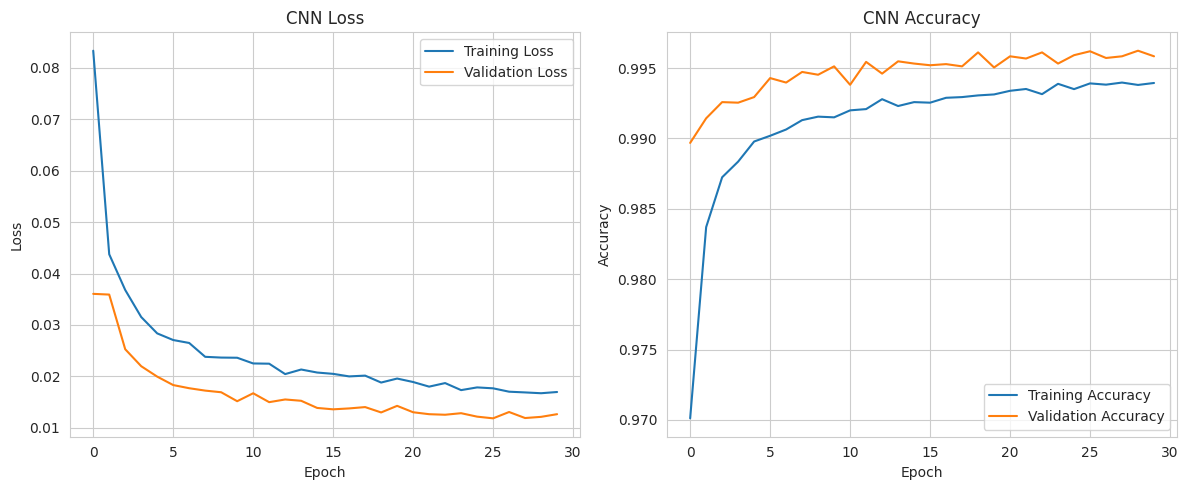

In [30]:
plot_training_history(history_cnn, title_prefix="CNN")

## 15. CNN modelinin değerlendirilmesi

CNN modeli test verisi üzerinde aşağıdaki metriklerle değerlendirilmiştir:

- Accuracy
- Precision
- Recall
- F1-score

Saldırı tespitinde özellikle recall önemlidir. Çünkü düşük recall, gerçek saldırıların bir kısmının kaçırıldığı anlamına gelir.

In [31]:
cnn_results, y_pred_cnn = evaluate_classification_model(
    cnn_model, X_test_cnn, y_test, model_name="CNN"
)

705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

CNN Sonuçları
----------------------------------------
Accuracy: 0.7819
Precision: 0.9250
Recall: 0.6712
F1-score: 0.7780

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.68      0.93      0.79      9711
           1       0.93      0.67      0.78     12833

    accuracy                           0.78     22544
   macro avg       0.80      0.80      0.78     22544
weighted avg       0.82      0.78      0.78     22544



## 16. CNN Confusion Matrix

Bu matris, modelin doğru ve yanlış tahminlerini daha açık şekilde görmek için kullanılmıştır.

Özellikle:
- doğru saldırı tespiti
- kaçırılan saldırılar
- yanlış alarmlar

bu tablo üzerinden incelenebilir.

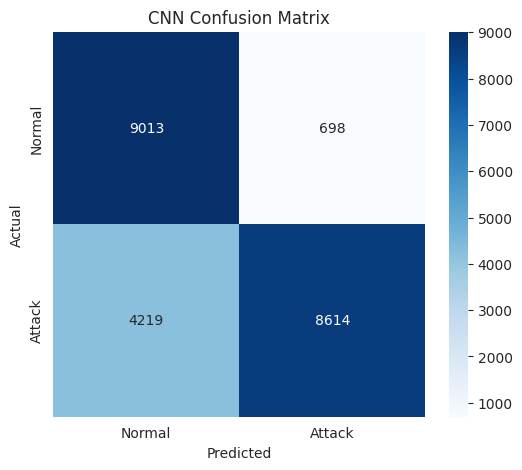

In [32]:
plot_confusion_matrix(y_test, y_pred_cnn, title="CNN Confusion Matrix", cmap="Blues")

## 17. Autoencoder modelinin kurulması

Bu bölümde ikinci yaklaşımın ilk aşaması olan Autoencoder kurulmuştur.

Autoencoder iki ana bölümden oluşur:
- Encoder: veriyi daha düşük boyutlu bir temsile dönüştürür
- Decoder: bu temsilden girdiyi yeniden üretmeye çalışır

Burada amaç doğrudan sınıflandırma yapmak değil, verinin daha özlü bir temsilini öğrenmektir.

In [33]:
input_dim = X_train_processed.shape[1]
encoding_dim = 32

input_layer = Input(shape=(input_dim,))

encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(64, activation="relu")(encoded)
latent = Dense(encoding_dim, activation="relu", name="latent_space")(encoded)

decoded = Dense(64, activation="relu")(latent)
decoded = Dense(128, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
encoder = Model(inputs=input_layer, outputs=latent)

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 122)            │        15,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,250 (204.10 KB)

 Trainable params: 52,250 (204.10 KB)

 Non-trainable params: 0 (0.00 B)

## 18. Autoencoder modelinin eğitilmesi

Autoencoder eğitilirken giriş ve hedef aynı veridir.

Yani model, verilen girdiyi sıkıştırıp tekrar üretmeye çalışmaktadır. Bu nedenle burada sınıf etiketi değil, giriş verisinin kendisi kullanılmaktadır.

In [34]:
history_ae = autoencoder.fit(
    X_train_processed, X_train_processed,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1377 - val_loss: 0.0572
Epoch 2/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0619 - val_loss: 0.0418
Epoch 3/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0511 - val_loss: 0.0365
Epoch 4/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0573 - val_loss: 0.0342
Epoch 5/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0374 - val_loss: 0.0435
Epoch 6/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0410 - val_loss: 0.0246
Epoch 7/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0314 - val_loss: 0.0323
Epoch 8/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0417 - val_loss: 0.0298
Epoch 9/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0238 - val_loss: 0.0407
Epoch 10/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0450 - val_loss: 0.0237
Epoch 11/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0276 - val_loss: 0.0235
Epoch 12/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

## 19. Autoencoder eğitim kaybının incelenmesi

Bu bölümde Autoencoder’ın giriş verisini ne kadar iyi yeniden üretebildiği incelenmiştir.

Burada izlenen değer sınıflandırma doğruluğu değil, reconstruction loss değeridir.

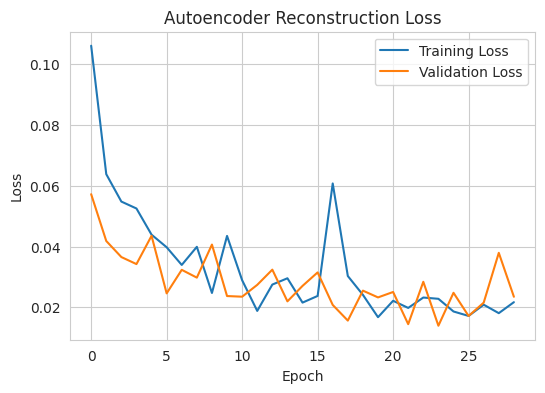

In [35]:
plt.figure(figsize=(6, 4))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 20. Encoder çıktılarının elde edilmesi

Autoencoder eğitildikten sonra yalnızca encoder kısmı kullanılmış ve her örnek için daha düşük boyutlu bir latent temsil elde edilmiştir.

Bu temsil daha sonra AE-CNN modelinin girdisi olarak kullanılmıştır.

In [36]:
X_train_encoded = encoder.predict(X_train_processed)
X_test_encoded = encoder.predict(X_test_processed)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape :", X_test_encoded.shape)

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Encoded train shape: (125973, 32)
Encoded test shape : (22544, 32)


## 21. AE-CNN için veri şekillendirme

Encoder çıktısı CNN’e verilebilmesi için tekrar uygun boyuta getirilmiştir.

In [37]:
X_train_ae_cnn = X_train_encoded.reshape(X_train_encoded.shape[0], X_train_encoded.shape[1], 1)
X_test_ae_cnn = X_test_encoded.reshape(X_test_encoded.shape[0], X_test_encoded.shape[1], 1)

print("AE-CNN train shape:", X_train_ae_cnn.shape)
print("AE-CNN test shape :", X_test_ae_cnn.shape)

AE-CNN train shape: (125973, 32, 1)
AE-CNN test shape : (22544, 32, 1)


## 22. AE-CNN modelinin kurulması

Bu modelde giriş olarak doğrudan işlenmiş veri değil, Autoencoder tarafından elde edilen latent temsil kullanılmıştır.

Model akışı şu şekildedir:

Ham veri -> Encoder -> Latent temsil -> CNN -> Tahmin

In [38]:
ae_cnn_model = build_cnn_model((X_train_ae_cnn.shape[1], 1))
ae_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,233 (122.00 KB)

 Non-trainable params: 192 (768.00 B)

## 23. AE-CNN modelinin eğitilmesi

Bu bölümde AE-CNN modeli eğitim verisi üzerinde eğitilmiştir.

Buradaki fark, CNN’in girişinin artık doğrudan veri değil, Autoencoder’dan gelen sıkıştırılmış temsil olmasıdır.

In [39]:
history_ae_cnn = ae_cnn_model.fit(
    X_train_ae_cnn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9386 - loss: 0.1753 - val_accuracy: 0.9846 - val_loss: 0.0443
Epoch 2/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9778 - loss: 0.0608 - val_accuracy: 0.9877 - val_loss: 0.0332
Epoch 3/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9826 - loss: 0.0474 - val_accuracy: 0.9883 - val_loss: 0.0302
Epoch 4/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9841 - loss: 0.0417 - val_accuracy: 0.9899 - val_loss: 0.0274
Epoch 5/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9844 - loss: 0.0391 - val_accuracy: 0.9908 - val_loss: 0.0258
Epoch 6/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9856 - loss: 0.0371 - val_accuracy: 0.9911 - val_loss: 0.0241
Epoch 7/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9864 - loss: 0.0349 - val_accuracy: 0.9910 - val_loss: 0.0260
Epoch 8/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9874 - loss: 0.0334 - 

## 24. AE-CNN eğitim grafiklerinin incelenmesi

Bu grafikler AE-CNN modelinin eğitim sürecini görmek için kullanılmıştır.
Daha sonra CNN ile AE-CNN’in öğrenme davranışları karşılaştırılabilir.

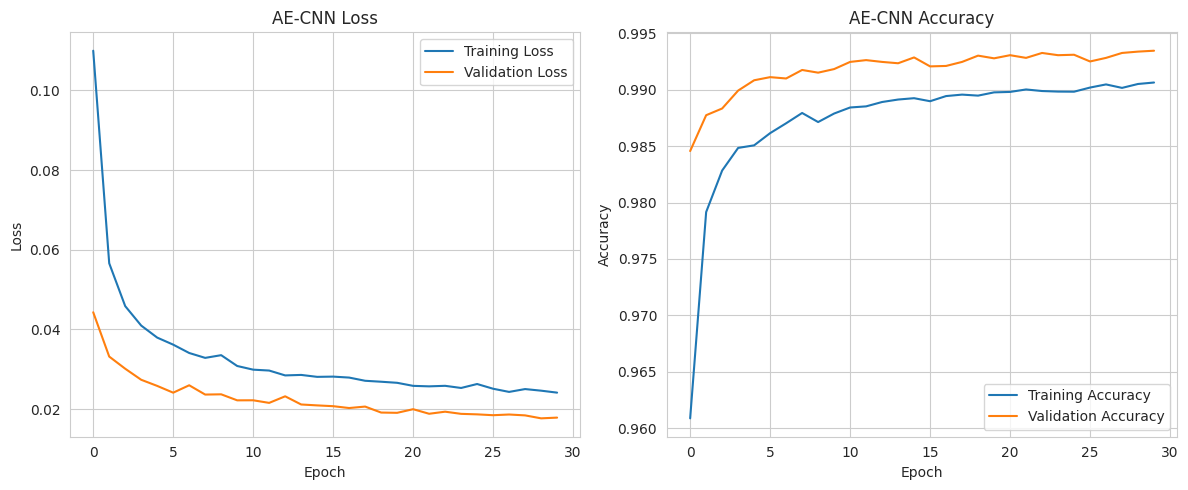

In [40]:
plot_training_history(history_ae_cnn, title_prefix="AE-CNN")

## 25. AE-CNN modelinin değerlendirilmesi

AE-CNN modeli de accuracy, precision, recall ve F1-score metrikleri ile değerlendirilmiştir.
Böylece iki model doğrudan karşılaştırılabilir hale gelmiştir.

In [41]:
ae_cnn_results, y_pred_ae_cnn = evaluate_classification_model(
    ae_cnn_model, X_test_ae_cnn, y_test, model_name="AE-CNN"
)

705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

AE-CNN Sonuçları
----------------------------------------
Accuracy: 0.7583
Precision: 0.9628
Recall: 0.5985
F1-score: 0.7381

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.96      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.78      0.76     22544
weighted avg       0.83      0.76      0.75     22544



## 26. AE-CNN Confusion Matrix

Bu matris, AE-CNN modelinin normal ve saldırı sınıflarındaki doğru ve yanlış tahminlerini incelemek için kullanılmıştır.

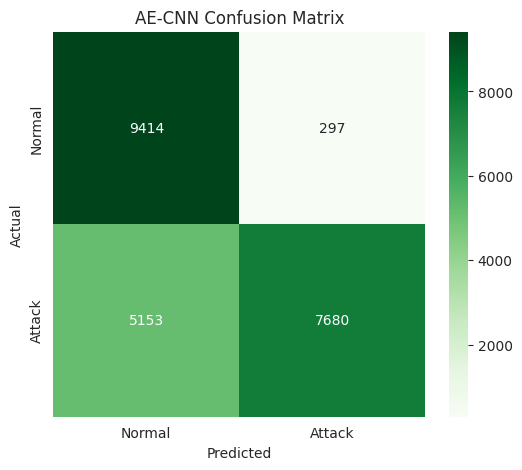

In [42]:
plot_confusion_matrix(y_test, y_pred_ae_cnn, title="AE-CNN Confusion Matrix", cmap="Greens")

## 27. CNN ve AE-CNN sonuçlarının karşılaştırılması

Bu bölümde iki modelin temel performans metrikleri aynı tabloda gösterilmiştir.

Böylece hangi modelin daha dengeli sonuç verdiği daha açık şekilde görülebilir.

In [43]:
results_df = pd.DataFrame([cnn_results, ae_cnn_results])
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score"]]

print(results_df.round(4))
results_df

    Model  Accuracy  Precision  Recall  F1-score
0     CNN    0.7819     0.9250  0.6712    0.7780
1  AE-CNN    0.7583     0.9628  0.5985    0.7381


,Model,Accuracy,Precision,Recall,F1-score
0,CNN,0.781893,0.925043,0.671238,0.777963
1,AE-CNN,0.758251,0.962768,0.598457,0.738107


## 28. Sonuçların grafikle karşılaştırılması

Tabloya ek olarak metriklerin grafikle gösterilmesi, iki modeli görsel olarak karşılaştırmayı kolaylaştırmaktadır.

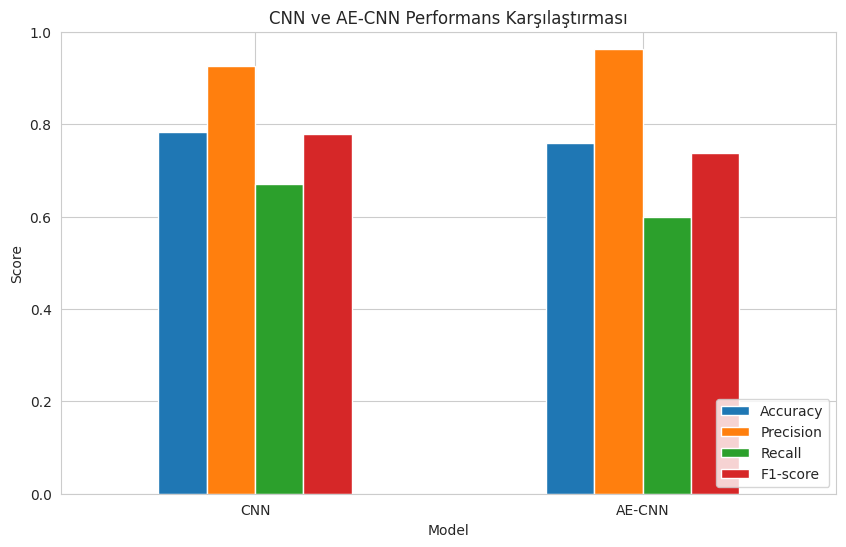

In [44]:
results_df_plot = results_df.set_index("Model")

results_df_plot.plot(kind="bar", figsize=(10, 6))
plt.title("CNN ve AE-CNN Performans Karşılaştırması")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 28.1 Kısa metrik özeti

Elde edilen sonuçlar aşağıdaki temel durumu göstermektedir:

- CNN modeli daha yüksek recall ve F1-score üretmiştir.
- AE-CNN modeli daha yüksek precision üretmiştir.
- Ancak saldırı tespiti açısından recall önemli olduğu için genel olarak CNN modeli daha uygun bulunmuştur.

## 29. Sonuçların değerlendirilmesi

Elde edilen sonuçlara göre **CNN modeli**, AE-CNN modeline göre daha dengeli bir performans göstermiştir.

Karşılaştırma yapıldığında:
- **CNN** modeli accuracy, recall ve F1-score açısından daha iyi sonuç vermiştir.
- **AE-CNN** modeli ise precision açısından daha yüksek bir değer üretmiştir.

Bu durum, AE-CNN modelinin saldırı dediğinde daha isabetli davrandığını; ancak daha fazla saldırıyı kaçırdığını göstermektedir.

Saldırı tespit sistemlerinde kaçırılan saldırılar önemli olduğu için **recall** metriği özel önem taşır. Bu açıdan bakıldığında CNN modeli daha uygun görünmektedir.

Autoencoder kullanımı ders slaytlarında anlatıldığı gibi verinin daha özlü bir temsilini öğrenmek için mantıklı bir yaklaşımdır. Ancak bu çalışmada elde edilen latent temsil, sınıflandırma başarısını artırmamıştır. Bu da Autoencoder tarafından öğrenilen temsilin verinin genel yapısını özetlese bile saldırı tespiti için gerekli bazı ayırt edici bilgileri yeterince koruyamamış olabileceğini düşündürmektedir.

Sonuç olarak bu çalışmada **genel performans açısından CNN modeli daha başarılı bulunmuştur**.

## 30. Genel özet

Bu çalışmada NSL-KDD veri seti üzerinde iki farklı yaklaşım karşılaştırılmıştır:

1. CNN
2. AE-CNN

İzlenen adımlar kısaca şöyledir:

1. Veri seti okunmuştur.
2. Etiketler ikili sınıflandırmaya dönüştürülmüştür.
3. difficulty sütunu çıkarılmıştır.
4. Kategorik ve sayısal sütunlar ayrılmıştır.
5. Kategorik değişkenlere one-hot encoding, sayısal değişkenlere standardizasyon uygulanmıştır.
6. CNN modeli eğitilip değerlendirilmiştir.
7. Autoencoder ile latent temsil elde edilmiştir.
8. Bu temsil kullanılarak AE-CNN modeli kurulup değerlendirilmiştir.
9. İki modelin sonuçları karşılaştırılmıştır.

Sonuçlara göre bu çalışmada CNN modeli daha dengeli ve daha başarılı bulunmuştur.